In [31]:
%pip install tensorflow
%pip install scikit-learn
%pip install Pillow
%pip install tqdm
%pip install nltk
%pip install matplotlib
%pip install numpy
%pip install seaborn
%pip install bert-score

from pathlib import Path
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add, BatchNormalization, concatenate
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm_notebook
from collections import Counter
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction, sentence_bleu
from nltk.translate.meteor_score import meteor_score
from tqdm import tqdm
from bert_score import score as bert_score
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import nltk
import tensorflow as tf
import textwrap

# Define the base directory and paths to images and captions
BASE_DIR = Path.cwd()
images = BASE_DIR / "archive" / "Images"
captions = BASE_DIR / "archive" / "captions.txt"
nltk.download('wordnet')
nltk.download('omw-1.4')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\colin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\colin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Data Loading (Captions & Images)

Loads raw caption data from a file and retrieves image file names from a directory.

In [6]:
# Function to load captions from the text file
def load_captions(file_path):
    with open(file_path, 'r') as f:
        captions = f.readlines()
        captions = [caption.lower().strip() for caption in captions[1:]]
    return captions

# Function to load image file names from the specified directory
def load_images(image_path):
    return [f for f in os.listdir(image_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

In [7]:
captions = load_captions(captions)
images = load_images(images)
print(captions[:15:3])
print(images[:15])
print("Captions loaded:", len(captions))
print("Images found:", len(images))
print("Sample captions:", captions[:5])
print("Sample images:", images[:5])

['1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set of stairs in an entry way .', '1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playhouse .', '1001773457_577c3a7d70.jpg,a black dog and a tri-colored dog playing with each other on the road .', '1001773457_577c3a7d70.jpg,two dogs on pavement moving toward each other .', '1002674143_1b742ab4b8.jpg,a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .']
['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg', '1007129816_e794419615.jpg', '1007320043_627395c3d8.jpg', '1009434119_febe49276a.jpg', '1012212859_01547e3f17.jpg', '1015118661_980735411b.jpg', '1015584366_dfcec3c85a.jpg', '101654506_8eb26cfb60.jpg', '101669240_b2d3e7f17b.jpg', '1016887272_03199f49c4.jpg', '1019077836_6fc9b15408.jpg', '1019604187_d087bf9a5f.jpg']
Captions loaded: 40455
Images found: 8091
Sample captions: ['1000268201_69

## Caption Cleaning & Preprocessing

Cleans raw caption text by removing noise and standardizing formatting for model training.

In [8]:
# Clean up captions by removing newlines and extra spaces
def clean_captions(captions):
    cleaned_captions = []
    for caption in captions:
        cleaned_caption = caption.split(',')[1]
        cleaned_caption = re.sub(r'[^\w\s]', '', cleaned_caption)
        cleaned_caption = re.sub(r'\d+', '', cleaned_caption)
        cleaned_caption = re.sub(r'\s+', ' ', cleaned_caption).strip()
        cleaned_captions.append(cleaned_caption)
    return cleaned_captions

cleaned_captions = clean_captions(captions)
print(f"Cleaned Captions: {cleaned_captions[:20:2]}")

Cleaned Captions: ['a child in a pink dress is climbing up a set of stairs in an entry way', 'a little girl climbing into a wooden playhouse', 'a little girl in a pink dress going into a wooden cabin', 'a black dog and a tricolored dog playing with each other on the road', 'two dogs of different breeds looking at each other on the road', 'a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl', 'a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it', 'young girl with pigtails painting outside in the grass', 'a man lays on the bench to which a white dog is also tied', 'a shirtless man lies on a park bench with his dog']


## Caption Formatting with Start/End Tokens

Creates formatted caption strings by pairing image IDs with cleaned captions and adding sequence boundary tokens.

### Purpose

- Associate each caption with its corresponding image ID  
- Add `"start"` and `"end"` tokens for sequence modeling  
- Prepare captions for tokenization and training  


In [9]:
def create_caption_ids(captions, cleaned_captions):
    captions_IDS = []
    for i in range(len(cleaned_captions)):
        item = captions[i].split(',')[0]+'\t' + 'start ' + cleaned_captions[i] + ' end\n'
        captions_IDS.append(item)
    return captions_IDS

captions_IDS = create_caption_ids(captions, cleaned_captions)

## Caption Visualization

Displays sample images along with their associated captions from the dataset.

### Parameters
- `captions_IDS`: list of image-caption pairs (`image_id \t caption`)
- `num_samples`: number of images to display  


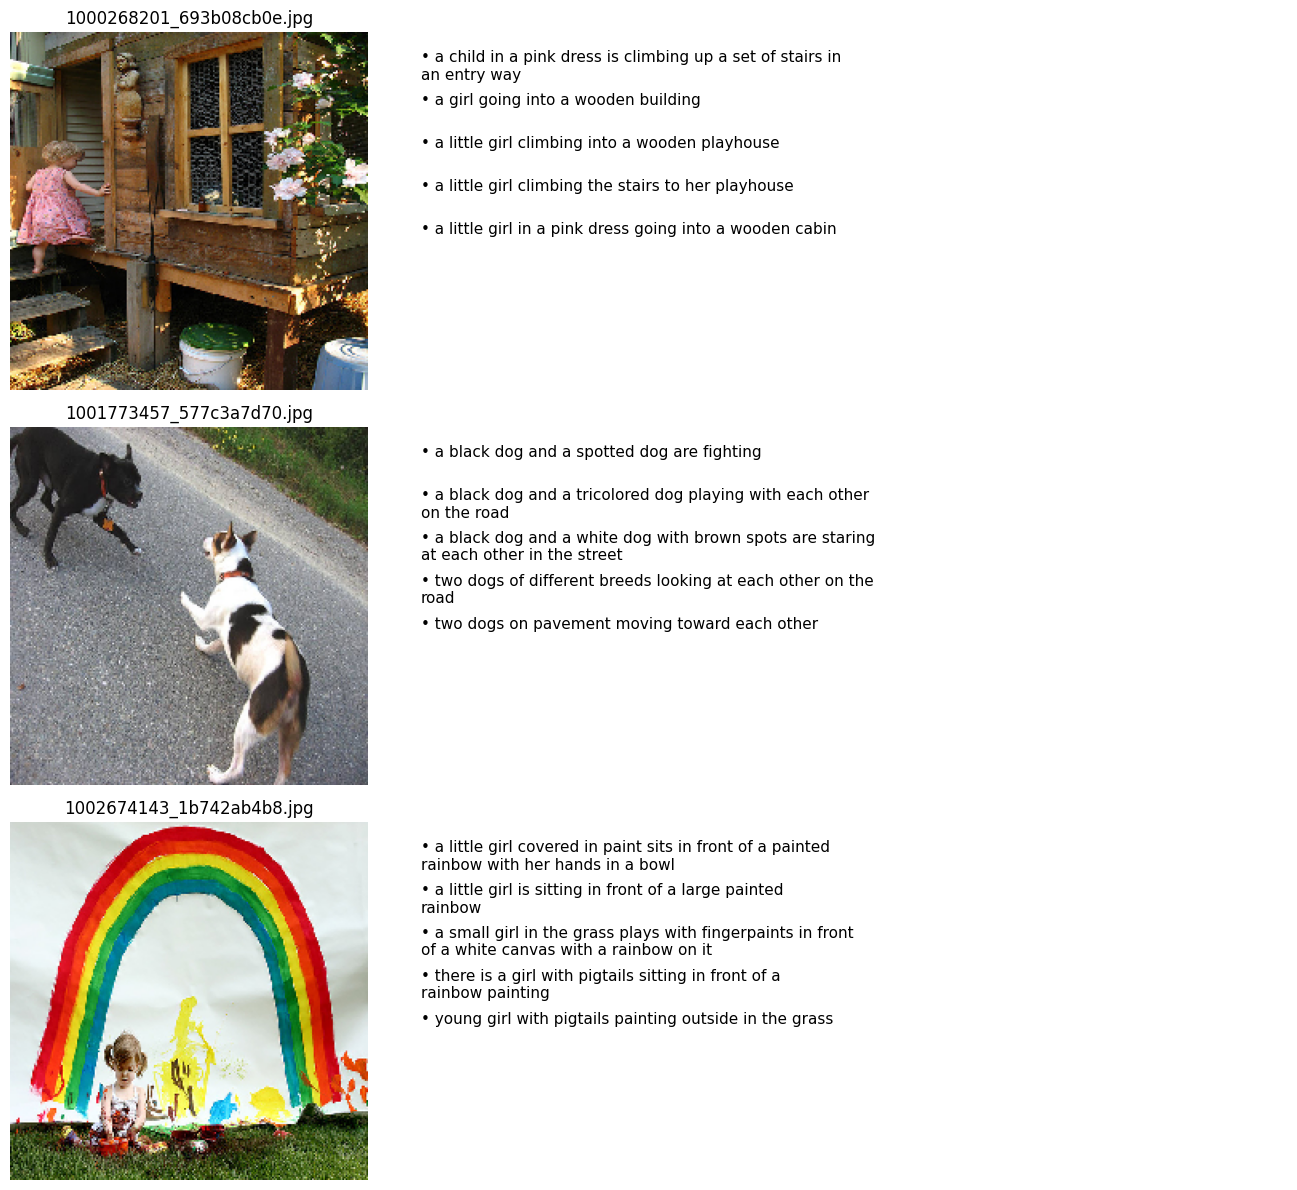

In [10]:
def visualize_captions(captions_IDS, num_samples=5):
    # Group captions by image
    caption_dict = {}
    for caption in captions_IDS:
        image_id, caption_text = caption.split('\t')
        clean_caption = ' '.join([
            word for word in caption_text.split()
            if word not in ['start', 'end']
        ])

        caption_dict.setdefault(image_id, []).append(clean_caption)

    # Sample images
    image_items = list(caption_dict.items())
    selected = image_items[:num_samples]

    fig, axes = plt.subplots(
        num_samples,
        2,
        figsize=(14, 4 * num_samples),
        gridspec_kw={'width_ratios': [1, 1.6]}
    )

    if num_samples == 1:
        axes = np.array([axes])

    for row, (image_id, captions) in enumerate(selected):
        # Load image
        img = image.load_img(
            str(BASE_DIR / "archive" / "Images" / image_id),
            target_size=(224, 224)
        )

        # LEFT: image
        ax_img = axes[row, 0]
        ax_img.imshow(img)
        ax_img.axis("off")
        ax_img.set_title(image_id, fontsize=12)

        # RIGHT: captions
        ax_text = axes[row, 1]
        ax_text.axis("off")

        y = 0.95
        for cap in captions:
            wrapped = textwrap.fill(f"• {cap}", width=60)
            ax_text.text(0, y, wrapped, fontsize=11, va='top')
            y -= 0.12

    plt.tight_layout()
    plt.show()

visualize_captions(captions_IDS, num_samples=3)

## Text Tokenization & Vocabulary Creation

Processes caption text and builds a vocabulary for the model.

In [11]:
all_captions = [caption.split('\t')[1].strip() for caption in captions_IDS]
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary Size: {vocab_size}")

Vocabulary Size: 8586


## Dataset Splitting (Train / Validation / Test)

Splits the dataset into:
- Training set (80%)  
- Validation set (10%)  
- Test set (10%)  


In [16]:
def split_dataset(images, captions_IDS):
    train_caption_id, temp_caption_id = train_test_split(images, test_size=0.2, random_state=42)
    val_captions_id, test_captions_id = train_test_split(temp_caption_id, test_size=0.5, random_state=42)
    train_caption, val_caption, test_caption = [], [], []
    for caption in captions_IDS: 
        image_id, _ = caption.split('\t', 1)
        if image_id in train_caption_id:
            train_caption.append(caption)
        elif image_id in val_captions_id:
            val_caption.append(caption)
        elif image_id in test_captions_id:
            test_caption.append(caption)
    return train_caption, val_caption, test_caption, train_caption_id, val_captions_id, test_captions_id

train_captions, val_captions, test_captions, train_caption_id, val_captions_id, test_captions_id = split_dataset(images, captions_IDS)
# print(f"Total captions: {len(images)}")
print(f"Sample training caption: {train_captions[0]}")
print(f"Sample validation caption: {val_captions[0]}")
print(f"Sample test caption: {test_captions[0]}")

Sample training caption: 1000268201_693b08cb0e.jpg	start a child in a pink dress is climbing up a set of stairs in an entry way end

Sample validation caption: 104136873_5b5d41be75.jpg	start people sit on the mountainside and check out the view end

Sample test caption: 1022454428_b6b660a67b.jpg	start a couple and an infant end



## Image Feature Extraction (ResNet50)

Extracts a fixed-length feature vector from an image using a pretrained **ResNet50** model.

### Purpose

- Convert raw images into **numerical feature vectors**  
- Use pretrained CNN knowledge (ImageNet)  
- Avoid training a CNN from scratch  


In [17]:
# Image feature extraction using a pretrained model (ResNet50)
# include_top=False removes the classifier
# pooling='avg' gives a single 2048-d feature vector for each image
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
# Function to extract features for a single image
def extract_image_features(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    features = model(img_array, training=False).numpy()  
    return features.flatten()

extract_image_features(str(BASE_DIR / "archive" / "Images" / images[0]), resnet_model)

array([0.0653655 , 0.16782731, 0.3251846 , ..., 0.05111521, 0.3281792 ,
       1.0043341 ], shape=(2048,), dtype=float32)

## Feature Extraction & Dataset Split

Extracts CNN image features and splits them into corresponding data sets.

### Purpose

- Convert raw images into **feature vectors** using a pretrained CNN  
- Organize features into train/validation/test sets  
- Prepare data for efficient model training  


In [18]:
# Splitting the dataset into training, validation and test sets
# We will use an 80-10-10 split for training, validation and testing respectively
train_image_embeddings, val_image_embeddings, test_image_embeddings = {}, {}, {}
# Function to extract features for the entire dataset
def extract_features_for_dataset(image_path, model, train_captions_id, val_captions_id, test_captions_id, train_image_embeddings, val_image_embeddings, test_image_embeddings):
    pbar = tqdm(total=len(image_path), desc="Extracting image features", ncols =80)
    for image_id in image_path:
        image_embedding = extract_image_features(str(BASE_DIR / "archive" / "Images" / image_id), model)
        if image_id in train_captions_id:
            train_image_embeddings[image_id] = image_embedding.flatten()
        elif image_id in val_captions_id:
            val_image_embeddings[image_id] = image_embedding.flatten()
        elif image_id in test_captions_id:
            test_image_embeddings[image_id] = image_embedding.flatten()
        pbar.update(1)
    pbar.close()
extract_features_for_dataset(images, resnet_model, train_caption_id, val_captions_id, test_captions_id, train_image_embeddings, val_image_embeddings, test_image_embeddings)
print(f"Extracted image features for training set: {len(train_image_embeddings)}")
print(f"Extracted image features for validation set: {len(val_image_embeddings)}")
print(f"Extracted image features for test set: {len(test_image_embeddings)}")

Extracting image features:   0%|                       | 0/8091 [00:00<?, ?it/s]

Extracting image features: 100%|████████████| 8091/8091 [30:46<00:00,  4.38it/s]

Extracted image features for training set: 6472
Extracted image features for validation set: 809
Extracted image features for test set: 810


## Data Generator for Image Captioning

Generates training data batches for the captioning model by converting
image–caption pairs into input-output sequences.

### Workflow

1. **Shuffle data**
   - Randomizes image order each epoch  

2. **Batch processing**
   - Processes captions in chunks of size `batch_size`  

3. **Tokenization**
   - Converts caption text into integer sequences  

4. **Sequence splitting**
   - Each caption:
     ```text
     "start a dog runs end"
     ```
     becomes:
     ```text
     [start] → a  
     [start a] → dog  
     [start a dog] → runs  
     ```

5. **Padding**
   - Ensures all sequences have fixed length  

6. **One-hot encoding**
   - Converts target word into vector form  

7. **Yield batch**
   - Returns:
     ```text
     (image_features, input_sequence) → next_word
     ```

In [19]:
def data_generator(captions, image_embeddings, tokenizer, max_caption_length, batch_size):
    num_samples = len(captions)
    image_ids = list(image_embeddings.keys())
    while True:
        np.random.shuffle(image_ids) # shuffle captions
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            x_images, x_captions, target = [], [], []
            for caption in captions[start:end]:
                image_id, caption_text = caption.split('\t')
                caption_text = caption_text.strip('\n')
                seq = tokenizer.texts_to_sequences([caption_text])[0] # convering the caption text to a sequence of intergs
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i] # split the sequence into input and output
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0] # pad the input sequence to a fixed length
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0] # convert the output sequence to one-hot encoding
                    x_images.append(image_embeddings[image_id])
                    x_captions.append(in_seq)
                    target.append(out_seq)
            yield (np.array(x_images), np.array(x_captions)), np.array(target) # yield the batch of data as a tuple of input and output

max_caption_length = max(len(caption.split()) for caption in cleaned_captions) + 2
cnn_output_dim = resnet_model.output_shape[1] # 2048

batch_size_train = 270
batch_size_val = 150

output_signature = (
    (
        tf.TensorSpec(shape=(None, cnn_output_dim), dtype=tf.float32),
        tf.TensorSpec(shape=(None, max_caption_length), dtype=tf.int32)
    ),
    tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32)
)

train_data_generator = tf.data.Dataset.from_generator(
    lambda: data_generator(train_captions, train_image_embeddings, tokenizer, max_caption_length, batch_size_train),
    output_signature=output_signature
)
val_data_generator = tf.data.Dataset.from_generator(
    lambda: data_generator(val_captions, val_image_embeddings, tokenizer, max_caption_length, batch_size_val),
    output_signature=output_signature
)

print(train_data_generator)
print(val_data_generator)

<_FlatMapDataset element_spec=((TensorSpec(shape=(None, 2048), dtype=tf.float32, name=None), TensorSpec(shape=(None, 35), dtype=tf.int32, name=None)), TensorSpec(shape=(None, 8586), dtype=tf.float32, name=None))>
<_FlatMapDataset element_spec=((TensorSpec(shape=(None, 2048), dtype=tf.float32, name=None), TensorSpec(shape=(None, 35), dtype=tf.int32, name=None)), TensorSpec(shape=(None, 8586), dtype=tf.float32, name=None))>


## Image Captioning Model (CNN + LSTM)

Builds a neural network that generates image captions by combining:
- Visual features from a CNN  
- Sequential language modeling using an LSTM  

### Architecture Overview

The model has **two input branches**:

1. **Image Branch**
   - Input: precomputed CNN feature vector  
   - Batch normalization → Dense layer → Dropout  
   - Learns a compact visual representation  

2. **Caption Branch**
   - Input: tokenized caption sequence  
   - Embedding layer → LSTM  
   - Learns contextual language representation  

3. **Fusion + Decoder**
   - Combines image + caption features using concatenation  
   - Passes through Dense + Dropout layers  
   - Outputs probability distribution over vocabulary  

In [20]:
def build_model(cnn_output_dim, max_caption_length, vocab_size):
    input_image = Input(shape=(cnn_output_dim,) , name='image_input')
    input_caption = Input(shape=(max_caption_length,), name='caption_input')
    # Image branch
    img = BatchNormalization()(input_image)
    img = Dense(256, activation='relu')(img)
    img = Dropout(0.5)(img)

    # Caption branch
    cap = Embedding(vocab_size, 256, mask_zero=True)(input_caption)
    cap = LSTM(256, dropout=0.3, recurrent_dropout=0.3)(cap)

    # Combine image + caption
    x = concatenate([img, cap])
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(vocab_size, activation='softmax', name='output')(x)
    model = Model(inputs=[input_image, input_caption], outputs=outputs, name='Image_Caption_Generator')
    return model

captain_model = build_model(cnn_output_dim, max_caption_length, vocab_size)
optimzer = Adam(learning_rate=0.001, clipnorm=1.0)
captain_model.compile(loss='categorical_crossentropy', optimizer=optimzer)
captain_model.summary()

Model: "Image_Caption_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ image_input[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 35, 256)   │  2,198,016 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 35)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8586)      │  2,206,602 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,593,994 (21.34 MB)

 Trainable params: 5,589,898 (21.32 MB)

 Non-trainable params: 4,096 (16.00 KB)

## Model Training with Callbacks

Trains the image captioning model using **early stopping** and **adaptive learning rate scheduling** to improve performance and prevent overfitting.

### Key Components

- **EarlyStopping**
  - Monitors `val_loss`
  - Stops training if no improvement for 3 epochs
  - Restores the best model weights

- **ReduceLROnPlateau**
  - Monitors `val_loss`
  - Reduces learning rate by 50% if performance plateaus
  - Helps fine-tune the model in later stages


### Training Process

- Uses data generators for efficient batching  
- Computes steps per epoch based on dataset size  
- Trains for up to 20 epochs (may stop early)


In [21]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
history = captain_model.fit(train_data_generator, 
                            steps_per_epoch=len(train_captions) // batch_size_train, 
                            validation_data=val_data_generator, 
                            validation_steps=len(val_captions) // batch_size_val, 
                            epochs=20, 
                            callbacks=[early_stopping, reduce_lr])

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - loss: 5.4222 - val_loss: 4.4732 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - loss: 4.1532 - val_loss: 3.8007 - learning_rate: 0.0010
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - loss: 3.7313 - val_loss: 3.5558 - learning_rate: 0.0010
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - loss: 3.4994 - val_loss: 3.4197 - learning_rate: 0.0010
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - loss: 3.3384 - val_loss: 3.3271 - learning_rate: 0.0010
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - loss: 3.2144 - val_loss: 3.2675 - learning_rate: 0.0010
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - loss: 3.1110 - val_loss: 3.2229 - learning_rate: 0.0010
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - loss: 3.0290 - val_loss: 3.1854 - learning_rate: 0.0010
Epoch 9/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - loss: 2.9573 - val_loss: 3.1648 - learning_rate: 0.0010
E

## Training vs Validation Loss Plot

Visualizes model performance over training epochs by comparing:
- Training loss  
- Validation loss  

### Parameters
- `history`: Keras History object returned from `model.fit()`


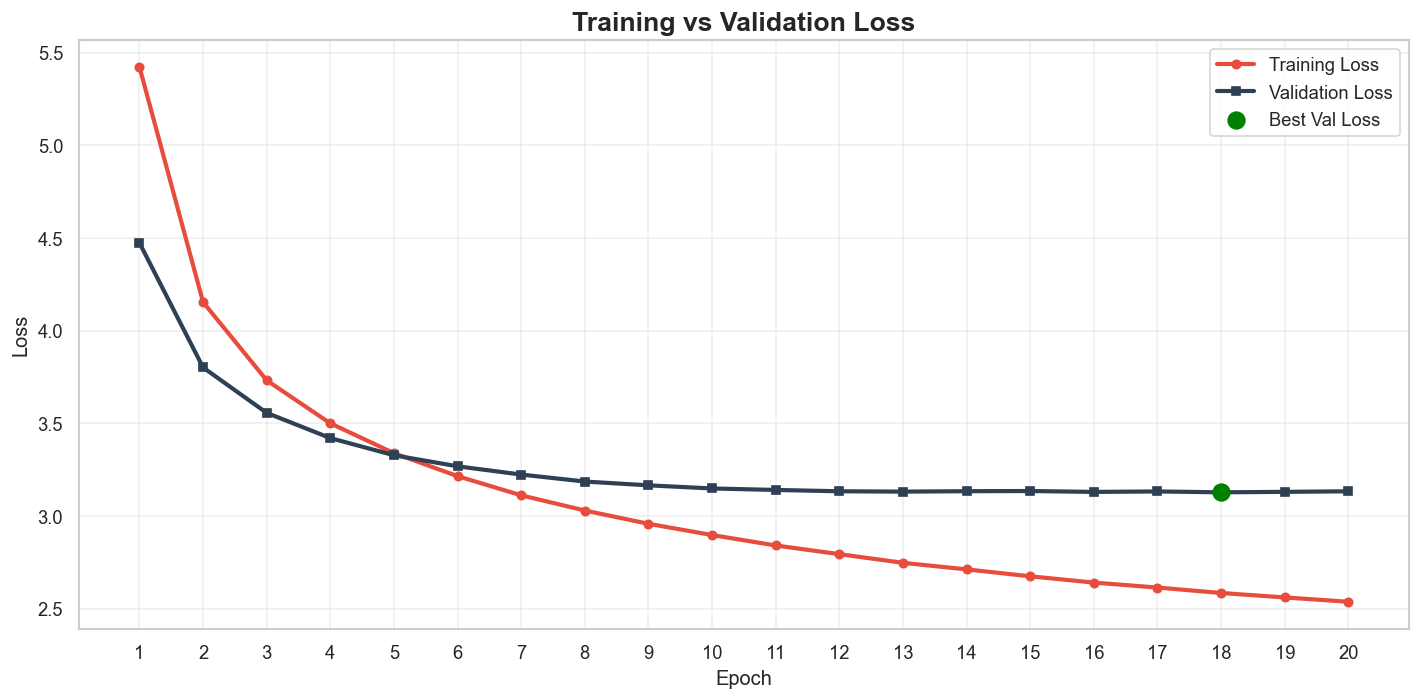

In [22]:
def plot_training_vs_validation_loss(history):
    sns.set_theme(style="whitegrid")
    epochs = range(1, len(history.history['loss']) + 1)
    plt.figure(figsize=(12, 6), dpi=120)

    # Plot lines
    plt.plot(
        epochs,
        history.history['loss'],
        label='Training Loss',
        color='#E74C3C',
        linewidth=2.5,
        marker='o',
        markersize=5
    )

    plt.plot(
        epochs,
        history.history['val_loss'],
        label='Validation Loss',
        color='#2E4053',
        linewidth=2.5,
        marker='s',
        markersize=5
    )

    # Highlight best validation point
    best_epoch = history.history['val_loss'].index(min(history.history['val_loss'])) + 1
    best_val = min(history.history['val_loss'])

    plt.scatter(best_epoch, best_val, color='green', s=100, zorder=5, label='Best Val Loss')

    # Labels and styling
    plt.title('Training vs Validation Loss', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)

    plt.xticks(epochs)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_vs_validation_loss(history)

## Greedy Search Caption Generator

Generates an image caption using **greedy decoding**, where the model selects the most probable next word at each step.

### Purpose

- Generate captions from image features  
- Provide a fast and simple decoding method  
- Serve as a baseline to compare with beam search  


In [40]:
def greedy_search_generator(image_features):
    start_token = tokenizer.word_index['start']
    end_token = tokenizer.word_index['end']

    # Start sequence with the start token
    token_seq = [start_token]

    for _ in range(max_caption_length):
        # Pad current sequence
        padded_seq = pad_sequences([token_seq], maxlen=max_caption_length)

        # Predict next token probabilities
        predictions = captain_model.predict(
            [image_features.reshape(1, -1), padded_seq],
            verbose=0
        )[0]

        # Pick the most likely next token
        next_token = np.argmax(predictions)

        # Append token to sequence
        token_seq.append(next_token)

        # Stop if end token is reached
        if next_token == end_token:
            break

    # Convert token indices back to words
    caption_words = []
    for token in token_seq:
        if token == start_token:
            continue
        if token == end_token:
            break
        word = tokenizer.index_word.get(token, '')
        caption_words.append(word)

    return ' '.join(caption_words)

## Beam Search Caption Generator

Generates captions for an image using **beam search decoding**, which keeps multiple candidate sequences to improve prediction quality.

### Parameters
- `image_features`: CNN feature vector for a single image  
- `K_beams`: number of beams (candidate sequences) to keep at each step  
- `log`: whether to use log probabilities for scoring (recommended)

### How it works
1. Starts with the `"start"` token  
2. At each step:
   - Predicts next-word probabilities  
   - Expands each beam with top `K_beams` words  
   - Scores each new sequence  
3. Keeps only the top `K_beams` sequences  
4. Stops early if all beams reach the `"end"` token  
5. Returns the highest-scoring caption  

### Key Idea
Instead of choosing one word at a time (greedy), beam search:
```text
keeps multiple possible captions → explores better sequences → improves results

In [23]:
def beam_search_generator(image_features, K_beams = 3, log = True):
    start_token = tokenizer.word_index['start']
    end_token = tokenizer.word_index['end']
    
    # Each beam is a tuple of (current_sequence, cumulative_log_probability)
    beams = [([start_token], 0.0)]  # Start with the start token and a log probability of 0
    for _ in range(max_caption_length):
        all_candidates = []
        for token_seq, score in beams:
            # If this token sequence already ends with the end token, add it to candidates and skip expansion
            if token_seq[-1] == end_token:
                all_candidates.append((token_seq, score))
                continue
            # Pad current sequence and predict next token probabilities
            padded_seq = pad_sequences([token_seq], maxlen=max_caption_length)
            # Predict the next token probabilities using the model
            predictions = captain_model.predict([image_features.reshape(1, -1), padded_seq], verbose=0)[0]
            # Get the top K token predictions
            top_k_indices = np.argsort(predictions)[-K_beams:]
            for idx in top_k_indices:
                new_seq = token_seq + [idx]
                if log:
                    # small value added to avoid log(0) which is undefined
                    new_score = score + np.log(predictions[idx] + 1e-10)  # Add small value to avoid log(0)
                else:
                    new_score = score * predictions[idx]
                all_candidates.append((new_seq, new_score))
        # Sort all candidates by score and select the top K beams for the next iteration
        beams = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:K_beams]
        # Stop early if all beams end with the end token
        if all(beam[0][-1] == end_token for beam in beams):
            break
    # Return the best sequence (the one with the highest score)
    best_sequence = beams[0][0]

    # Convert token indices back to words
    caption_words = []
    for token in best_sequence:
        if token == start_token:
            continue  # Skip the start token
        if token == end_token:
            break
        word = tokenizer.index_word.get(token, '')
        caption_words.append(word)
    return ' '.join(caption_words)

## BLEU & METEOR & BERT_F1 Scoring Function

Computes evaluation scores for a single generated caption using:
- BLEU-4
- METEOR
- BERT_F1

### Parameters
- `actual`: list of ground truth captions (strings)
- `predicted`: generated caption (string)

In [37]:
def bleu_meteor_bert_score(actual, predicted):
    smooth = SmoothingFunction().method1

    # Clean references as strings
    reference_strings = [
        ' '.join([w for w in cap.split() if w not in ['start', 'end']])
        for cap in actual
    ]

    # Tokenized versions for BLEU / METEOR
    actual_tokens = [ref.split() for ref in reference_strings]
    predicted_tokens = predicted.split()

    # BLEU-4
    bleu = corpus_bleu(
        [actual_tokens],
        [predicted_tokens],
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    # METEOR
    meteor = meteor_score(actual_tokens, predicted_tokens)

    # BERTScore
    candidates = [predicted] * len(reference_strings)
    P, R, F1 = bert_score(
        candidates,
        reference_strings,
        lang="en",
        verbose=False
    )
    bert_f1 = F1.max().item()

    return {
        "BLEU-4": round(float(bleu), 5),
        "METEOR": round(float(meteor), 5),
        "BERTScore F1": round(float(bert_f1), 5)
    }

## Visualization Function

Displays random test images with:
- Ground truth captions
- Beam search generated caption
- Greedy search generated caption
- Evaluation metrics (BLEU, METEOR, BERT)

### Parameters
- `data`: dict mapping `image_id → list of captions`
- `image_features`: dict mapping `image_id → feature vector`
- `beam_generator`: function to generate captions using beam search
- `greedy_generator`: function to generate captions using greedy search
- `evaluator`: function to compute evaluation scores
- `num_of_images`: number of images to display

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 9466.86it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5495.31it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status    

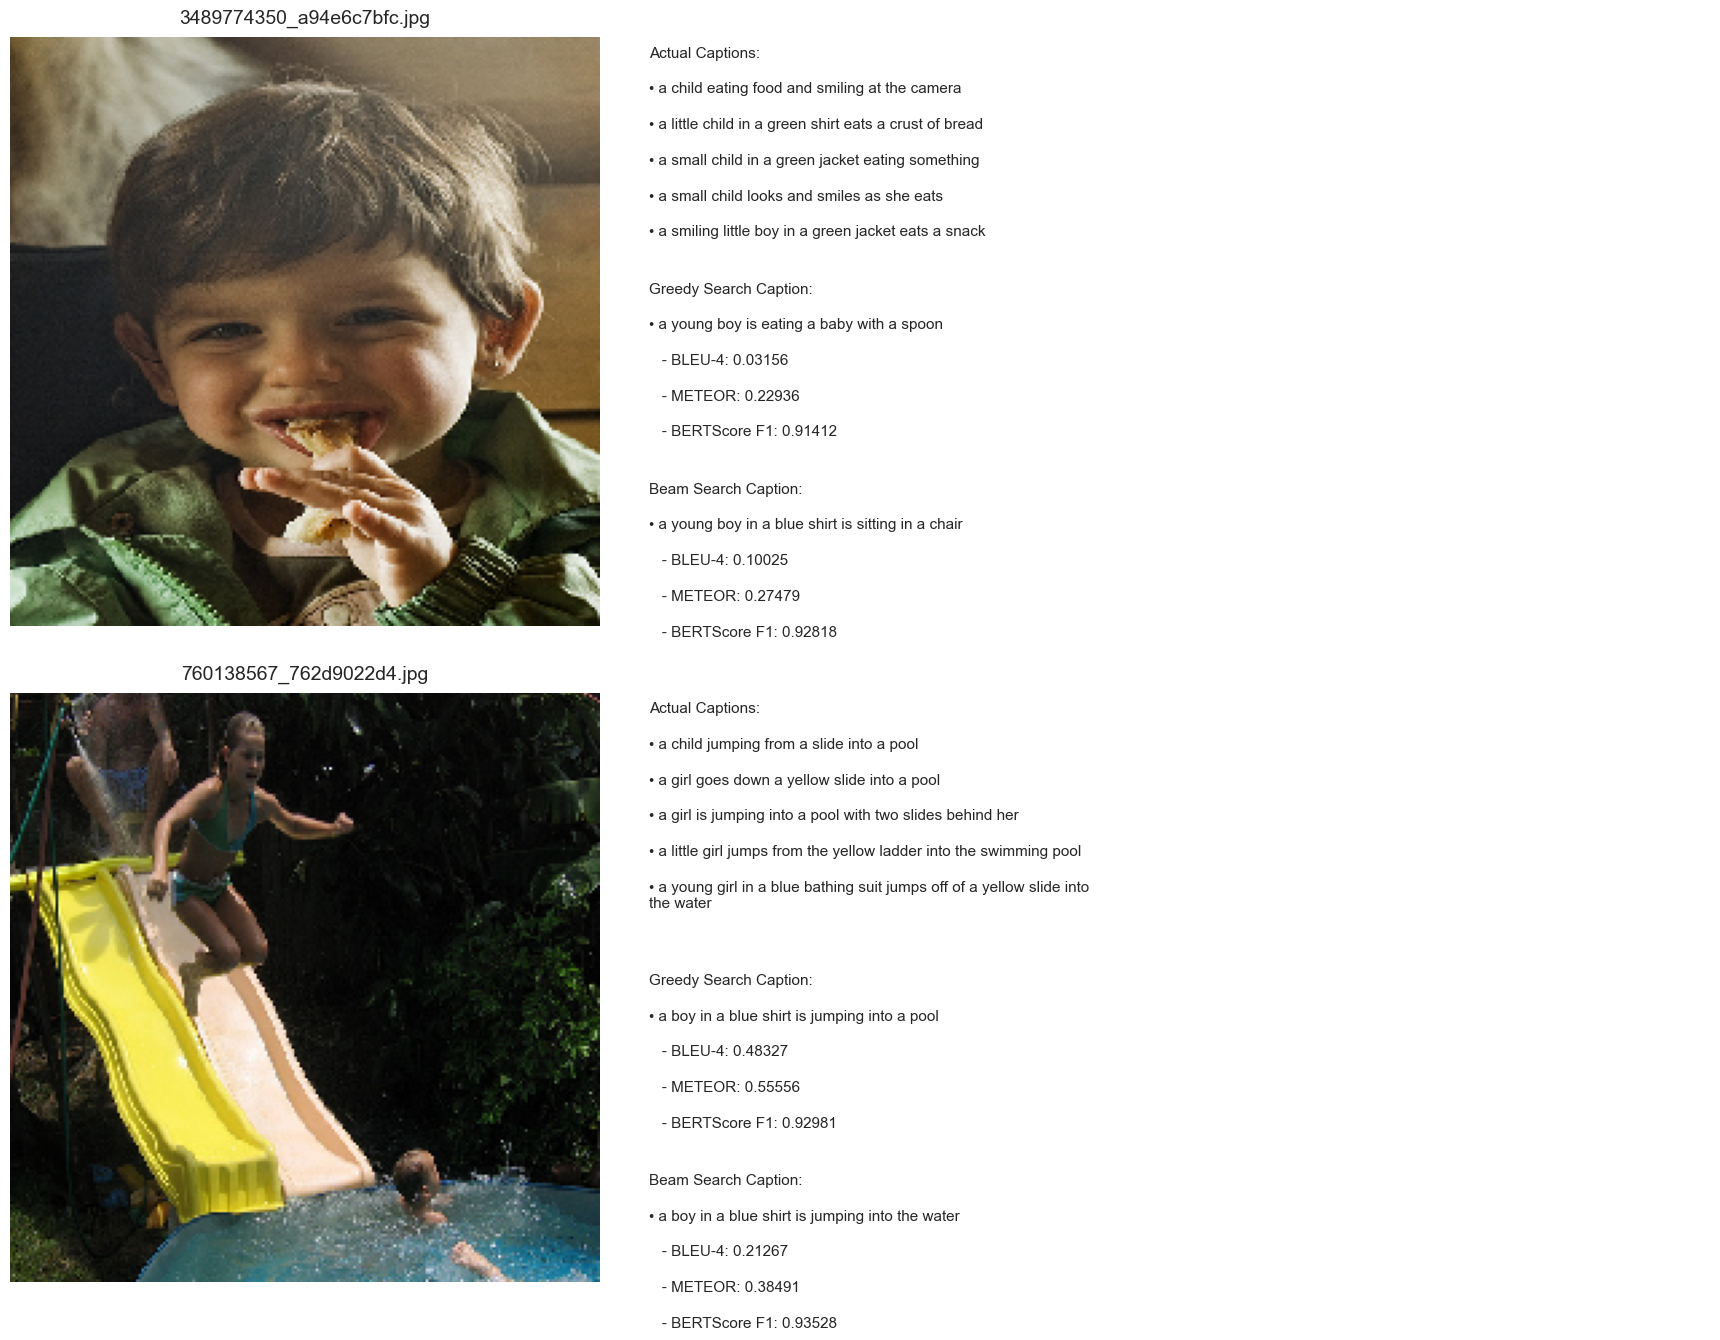

In [48]:
def visualization_compare_search(
    data,
    image_features,
    greedy_generator,
    beam_generator,
    evaluator,
    num_of_images
):
    filenames = list(data.keys())
    selected_images = np.random.choice(filenames, num_of_images, replace=False)
    images_directory = str(BASE_DIR / "archive" / "Images") + os.sep

    fig, axes = plt.subplots(
        num_of_images,
        2,
        figsize=(18, 7 * num_of_images),
        gridspec_kw={'width_ratios': [1, 1.8]}
    )

    if num_of_images == 1:
        axes = np.array([axes])

    for row, filename in enumerate(selected_images):
        actual_cap = data[filename]
        actual_cap = [
            ' '.join([w for w in caption.split() if w not in ['start', 'end']])
            for caption in actual_cap
        ]

        greedy_cap = greedy_generator(image_features[filename])
        beam_cap = beam_generator(image_features[filename])

        greedy_scores = evaluator(actual_cap, greedy_cap)
        beam_scores = evaluator(actual_cap, beam_cap)

        # Left: image
        ax_img = axes[row, 0]
        image_load = load_img(os.path.join(images_directory, filename), target_size=(220, 220))
        ax_img.imshow(image_load)
        ax_img.axis('off')
        ax_img.set_title(filename, fontsize=14, pad=10)

        # Right: text
        ax_text = axes[row, 1]
        ax_text.axis('off')

        lines = []
        lines.append("Actual Captions:")
        for caption in actual_cap:
            lines.append(textwrap.fill(f"• {caption}", width=70))

        lines.append("")
        lines.append("Greedy Search Caption:")
        lines.append(textwrap.fill(f"• {greedy_cap}", width=70))

        if isinstance(greedy_scores, dict):
            for key, value in greedy_scores.items():
                lines.append(f"   - {key}: {value}")

        lines.append("")
        lines.append("Beam Search Caption:")
        lines.append(textwrap.fill(f"• {beam_cap}", width=70))

        if isinstance(beam_scores, dict):
            for key, value in beam_scores.items():
                lines.append(f"   - {key}: {value}")

        y = 0.98
        line_height = 0.06

        for line in lines:
            if line == "":
                y -= line_height * 0.6
            else:
                ax_text.text(
                    0.0, y, line,
                    fontsize=11,
                    va='top',
                    ha='left',
                    wrap=True
                )
                wrapped_line_count = line.count("\n") + 1
                y -= line_height * wrapped_line_count

    plt.tight_layout(pad=3.0)
    plt.show()

# Before calling visualization, filter caption_dict to only test images
caption_dict = {}
for caption in captions_IDS:
    image_id, caption_text = caption.split('\t')
    if image_id in test_image_embeddings:  # Only add if in test set
        if image_id not in caption_dict:
            caption_dict[image_id] = []
        caption_dict[image_id].append(caption_text.strip())

visualization_compare_search(caption_dict, test_image_embeddings, greedy_search_generator, beam_search_generator, bleu_meteor_bert_score, 2)

## Evaluation Function (Mean Scores)

Computes average performance of the model with beam search vs greedy search over a random sample of test images using:
- BLEU-4
- METEOR
- BERT_F1

### Parameters
- `image_features`: dict mapping `image_id → feature vector`
- `caption_dict`: dict mapping `image_id → list of captions`
- `beam_search_generator`: function to generate captions using beam search
- `greedy_search_generator`: function to generate captions using greedy search
- `n_samples`: number of images to evaluate

In [49]:
def evaluate_mean_scores_compare(
    image_features,
    caption_dict,
    greedy_search_generator,
    beam_search_generator,
    n_samples=100
):
    smooth = SmoothingFunction().method1

    image_ids = list(image_features.keys())
    n_samples = min(n_samples, len(image_ids))
    sampled_ids = np.random.choice(image_ids, n_samples, replace=False)

    greedy_bleu_scores = []
    greedy_meteor_scores = []
    greedy_bert_f1_scores = []

    beam_bleu_scores = []
    beam_meteor_scores = []
    beam_bert_f1_scores = []

    for img_id in tqdm(sampled_ids, desc="Evaluating captions"):
        # Clean reference captions
        reference_strings = [
            ' '.join([w for w in cap.split() if w not in ['start', 'end']])
            for cap in caption_dict[img_id]
        ]
        references = [ref.split() for ref in reference_strings]

        # Generate captions
        greedy_prediction = greedy_search_generator(image_features[img_id]).strip()
        beam_prediction = beam_search_generator(image_features[img_id]).strip()

        greedy_candidate = greedy_prediction.split()
        beam_candidate = beam_prediction.split()

        # GREEDY: BLEU
        greedy_bleu = sentence_bleu(
            references,
            greedy_candidate,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth
        )

        # GREEDY: METEOR
        greedy_meteor = meteor_score(references, greedy_candidate)

        # GREEDY: BERTScore
        greedy_candidates = [greedy_prediction] * len(reference_strings)
        _, _, greedy_F1 = bert_score(
            greedy_candidates,
            reference_strings,
            lang="en",
            verbose=False
        )
        greedy_best_f1 = greedy_F1.max().item()

        # BEAM: BLEU
        beam_bleu = sentence_bleu(
            references,
            beam_candidate,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth
        )

        # BEAM: METEOR
        beam_meteor = meteor_score(references, beam_candidate)

        # BEAM: BERTScore
        beam_candidates = [beam_prediction] * len(reference_strings)
        _, _, beam_F1 = bert_score(
            beam_candidates,
            reference_strings,
            lang="en",
            verbose=False
        )
        beam_best_f1 = beam_F1.max().item()

        greedy_bleu_scores.append(greedy_bleu)
        greedy_meteor_scores.append(greedy_meteor)
        greedy_bert_f1_scores.append(greedy_best_f1)

        beam_bleu_scores.append(beam_bleu)
        beam_meteor_scores.append(beam_meteor)
        beam_bert_f1_scores.append(beam_best_f1)

    return {
        "Greedy Search": {
            "Mean BLEU-4": round(float(np.mean(greedy_bleu_scores)), 5),
            "Mean METEOR": round(float(np.mean(greedy_meteor_scores)), 5),
            "Mean BERTScore F1": round(float(np.mean(greedy_bert_f1_scores)), 5),
        },
        "Beam Search": {
            "Mean BLEU-4": round(float(np.mean(beam_bleu_scores)), 5),
            "Mean METEOR": round(float(np.mean(beam_meteor_scores)), 5),
            "Mean BERTScore F1": round(float(np.mean(beam_bert_f1_scores)), 5),
        },
        "Num Samples": n_samples
    }

In [50]:
results = evaluate_mean_scores_compare(
    test_image_embeddings,
    caption_dict,
    greedy_search_generator,
    beam_search_generator,
    n_samples=50
)

results

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5834.21it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5570.14it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status    

{'Greedy Search': {'Mean BLEU-4': 0.12821,
  'Mean METEOR': 0.38447,
  'Mean BERTScore F1': 0.92973},
 'Beam Search': {'Mean BLEU-4': 0.15399,
  'Mean METEOR': 0.41592,
  'Mean BERTScore F1': 0.93185},
 'Num Samples': 50}